# Step 12: Multi-Crop Target Selection & Chronological Train/Test Split
## MandiMitra ML Pipeline — Tomato, Wheat, Cotton

Strict 80/20 chronological split per crop. No random shuffling. No leakage.

### 1. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
BASE_DIR = Path('..').resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))
from src.multi_crop_train_test_split import split_all_crops
print('Step 12: Target Selection & Chronological Split')

Step 12: Target Selection & Chronological Split


### 2. Run Split Pipeline

In [2]:
split_results = split_all_crops(verbose=True)


TARGET SELECTION & SPLIT: TOMATO

  Target Comparison:
                    target  valid_observations    mean  median     std   min    max  persistence_MAE  ma7_MAE
    price_next_observation                2122 2281.74  2025.0 1144.56 300.0 7500.0         310.4138 370.7113
price_after_3_observations                2114 2285.07  2050.0 1144.47 300.0 7500.0         408.1173 409.4204
price_after_7_observations                2098 2293.25  2100.0 1143.47 300.0 7500.0         485.6072 494.4966

  Selected Primary Target: price_after_3_observations
  80/20 Cutoff date: 2026-05-13
    Train | APMC Kamthi | Local | Local: 400 rows
    Train | APMC Panvel | Other | Local: 415 rows
    Train | Pune(Manjri) | Other | Local: 426 rows
    Train | Pune(Pimpri) | Local | Local: 450 rows

  Split Summary:
    Total rows        : 2,126
    Train rows        : 1,691
    Test rows         : 423
    Valid test targets: 411
    Rows purged       : 12

  Saved train : data/processed/maharashtra_tomato_tra


  Saved train : data/processed/maharashtra_wheat_train.csv
  Saved test  : data/processed/maharashtra_wheat_test.csv
  Saved summary: outputs/splits/wheat_split_summary.csv

TARGET SELECTION & SPLIT: COTTON



  Target Comparison:
                    target  valid_observations    mean  median    std    min    max  persistence_MAE  ma7_MAE
    price_next_observation                 411 7262.12  7200.0 624.18 4700.0 8500.0          59.7421  79.6768
price_after_3_observations                 409 7265.85  7200.0 623.42 4700.0 8500.0          83.1394  91.9240
price_after_7_observations                 405 7273.17  7200.0 622.09 4700.0 8500.0         110.2667 113.7380

  Selected Primary Target: price_after_3_observations
  80/20 Cutoff date: 2026-02-12
    Train | APMC Hinganghat | Other | FAQ: 326 rows

  Split Summary:
    Total rows        : 412
    Train rows        : 326
    Test rows         : 83
    Valid test targets: 80
    Rows purged       : 3

  Saved train : data/processed/maharashtra_cotton_train.csv
  Saved test  : data/processed/maharashtra_cotton_test.csv
  Saved summary: outputs/splits/cotton_split_summary.csv


### 3. Target Comparison Tables

In [3]:
for crop in ['Tomato','Wheat','Cotton']:
    p = BASE_DIR/'outputs'/'target_selection'/f'{crop.lower()}_target_comparison.csv'
    tc = pd.read_csv(p)
    print(f'\n{crop} — Target Comparison:')
    display(tc)


Tomato — Target Comparison:


,target,valid_observations,mean,median,std,min,max,persistence_MAE,ma7_MAE
0,price_next_observation,2122,2281.74,2025.0,1144.56,300.0,7500.0,310.4138,370.7113
1,price_after_3_observations,2114,2285.07,2050.0,1144.47,300.0,7500.0,408.1173,409.4204
2,price_after_7_observations,2098,2293.25,2100.0,1143.47,300.0,7500.0,485.6072,494.4966



Wheat — Target Comparison:


,target,valid_observations,mean,median,std,min,max,persistence_MAE,ma7_MAE
0,price_next_observation,12184,2901.53,2700.0,469.61,1700.0,4774.0,70.0064,71.3984
1,price_after_3_observations,12142,2901.84,2700.0,469.43,1700.0,4774.0,79.9200,77.2440
2,price_after_7_observations,12058,2902.42,2700.5,469.15,1700.0,4774.0,93.1090,87.4164



Cotton — Target Comparison:


,target,valid_observations,mean,median,std,min,max,persistence_MAE,ma7_MAE
0,price_next_observation,411,7262.12,7200.0,624.18,4700.0,8500.0,59.7421,79.6768
1,price_after_3_observations,409,7265.85,7200.0,623.42,4700.0,8500.0,83.1394,91.9240
2,price_after_7_observations,405,7273.17,7200.0,622.09,4700.0,8500.0,110.2667,113.7380


### 4. Split Summary Tables

In [4]:
for crop in ['Tomato','Wheat','Cotton']:
    p = BASE_DIR/'outputs'/'splits'/f'{crop.lower()}_split_summary.csv'
    ss = pd.read_csv(p)
    print(f'\n{crop} — Split Summary:')
    display(ss)


Tomato — Split Summary:


,crop,primary_target,cutoff_date,train_start,train_end,test_start,test_end,total_rows,train_rows,test_rows,valid_test_target_rows,rows_purged
0,Tomato,price_after_3_observations,2026-05-13,2025-01-26,2026-05-10,2026-05-14,2026-09-03,2126,1691,423,411,12



Wheat — Split Summary:


,crop,primary_target,cutoff_date,train_start,train_end,test_start,test_end,total_rows,train_rows,test_rows,valid_test_target_rows,rows_purged
0,Wheat,price_after_3_observations,2025-12-17,2024-01-01,2025-12-13,2025-12-18,2026-09-03,12205,9712,2430,2367,63



Cotton — Split Summary:


,crop,primary_target,cutoff_date,train_start,train_end,test_start,test_end,total_rows,train_rows,test_rows,valid_test_target_rows,rows_purged
0,Cotton,price_after_3_observations,2026-02-12,2024-01-01,2026-02-05,2026-02-13,2026-06-10,412,326,83,80,3


### 5. Verify Chronological Order

In [5]:
print('CHRONOLOGICAL ORDER VERIFICATION:')
for crop in ['Tomato','Wheat','Cotton']:
    train = pd.read_csv(BASE_DIR/'data'/'processed'/f'maharashtra_{crop.lower()}_train.csv')
    test = pd.read_csv(BASE_DIR/'data'/'processed'/f'maharashtra_{crop.lower()}_test.csv')
    train['Price Date'] = pd.to_datetime(train['Price Date'])
    test['Price Date'] = pd.to_datetime(test['Price Date'])
    ok = train['Price Date'].max() < test['Price Date'].min()
    print(f'  [{"PASSED" if ok else "FAILED"}] {crop}: train ends {train["Price Date"].max().date()} < test starts {test["Price Date"].min().date()}')

CHRONOLOGICAL ORDER VERIFICATION:
  [PASSED] Tomato: train ends 2026-05-10 < test starts 2026-05-14
  [PASSED] Wheat: train ends 2025-12-13 < test starts 2025-12-18
  [PASSED] Cotton: train ends 2026-02-05 < test starts 2026-02-13


### 6. No NaN in Primary Target (Train Set)

In [6]:
primary_targets = {'Tomato':'price_after_3_observations','Wheat':'price_after_3_observations','Cotton':'price_after_3_observations'}
print('TARGET NaN CHECK (train set):')
for crop, tgt in primary_targets.items():
    train = pd.read_csv(BASE_DIR/'data'/'processed'/f'maharashtra_{crop.lower()}_train.csv')
    nan_count = train[tgt].isna().sum() if tgt in train.columns else 'N/A'
    print(f'  [{"PASSED" if nan_count == 0 else "CHECK"}] {crop} train set {tgt} NaN = {nan_count}')

TARGET NaN CHECK (train set):
  [PASSED] Tomato train set price_after_3_observations NaN = 0
  [PASSED] Wheat train set price_after_3_observations NaN = 0
  [PASSED] Cotton train set price_after_3_observations NaN = 0


### 7. Train/Test Size Visualization

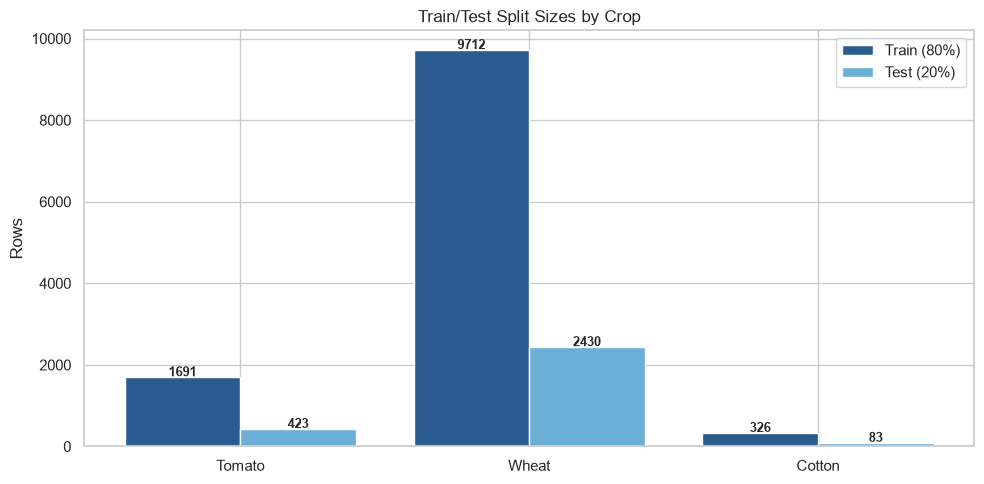

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
crops_list = ['Tomato','Wheat','Cotton']
train_sizes, test_sizes = [], []
for crop in crops_list:
    train = pd.read_csv(BASE_DIR/'data'/'processed'/f'maharashtra_{crop.lower()}_train.csv')
    test = pd.read_csv(BASE_DIR/'data'/'processed'/f'maharashtra_{crop.lower()}_test.csv')
    train_sizes.append(len(train)); test_sizes.append(len(test))
x = range(len(crops_list))
ax.bar(x, train_sizes, label='Train (80%)', color='#2b5c8f', width=0.4)
ax.bar([i+0.4 for i in x], test_sizes, label='Test (20%)', color='#6baed6', width=0.4)
ax.set_xticks([i+0.2 for i in x]); ax.set_xticklabels(crops_list)
ax.set_ylabel('Rows'); ax.set_title('Train/Test Split Sizes by Crop'); ax.legend()
for i,v in enumerate(train_sizes): ax.text(i, v+30, str(v), ha='center', fontsize=9, fontweight='bold')
for i,v in enumerate(test_sizes): ax.text(i+0.4, v+30, str(v), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'splits'/'multi_crop_train_test_sizes.png', dpi=120, bbox_inches='tight')
plt.show()

### 8. Persistence & MA-7 Baseline per Crop

In [8]:
print('BASELINE BENCHMARKS PER CROP (from target comparison):')
for crop in ['Tomato','Wheat','Cotton']:
    tc = pd.read_csv(BASE_DIR/'outputs'/'target_selection'/f'{crop.lower()}_target_comparison.csv')
    row = tc[tc['target'] == 'price_after_3_observations'].iloc[0]
    print(f'  {crop}:')
    print(f'    Persistence MAE = ₹{row["persistence_MAE"]:.2f}')
    print(f'    MA-7 MAE        = ₹{row["ma7_MAE"]:.2f}')
    print(f'    Valid obs (test target): {row["valid_observations"]:,}')

BASELINE BENCHMARKS PER CROP (from target comparison):
  Tomato:
    Persistence MAE = ₹408.12
    MA-7 MAE        = ₹409.42
    Valid obs (test target): 2,114


  Wheat:
    Persistence MAE = ₹79.92
    MA-7 MAE        = ₹77.24
    Valid obs (test target): 12,142
  Cotton:
    Persistence MAE = ₹83.14
    MA-7 MAE        = ₹91.92
    Valid obs (test target): 409


### 9. Rice Protection Final Check

In [9]:
print('RICE PROTECTION CHECK:')
rice_checks = [
    ('data/processed/maharashtra_2024_2026_combined.csv', 'Rice data'),
    ('data/processed/maharashtra_rice_modeling_clean.csv', 'Rice clean'),
    ('data/processed/maharashtra_rice_features.csv', 'Rice features'),
    ('data/processed/maharashtra_rice_train.csv', 'Rice train'),
    ('data/processed/maharashtra_rice_test.csv', 'Rice test'),
    ('models/mandimitra_rice_price_model.joblib', 'Rice model'),
    ('models/model_metadata.json', 'Rice metadata'),
]
for rel_path, label in rice_checks:
    p = BASE_DIR/rel_path
    print(f'  [{"OK" if p.exists() else "MISSING"}] {label}: {rel_path}')

RICE PROTECTION CHECK:
  [OK] Rice data: data/processed/maharashtra_2024_2026_combined.csv
  [OK] Rice clean: data/processed/maharashtra_rice_modeling_clean.csv
  [OK] Rice features: data/processed/maharashtra_rice_features.csv
  [OK] Rice train: data/processed/maharashtra_rice_train.csv
  [OK] Rice test: data/processed/maharashtra_rice_test.csv
  [OK] Rice model: models/mandimitra_rice_price_model.joblib
  [OK] Rice metadata: models/model_metadata.json


### 10. Final Summary Block

In [10]:
import pandas as pd
from pathlib import Path
BASE_DIR = Path('..').resolve()

def get_split_info(crop):
    ss = pd.read_csv(BASE_DIR/'outputs'/'splits'/f'{crop.lower()}_split_summary.csv').iloc[0]
    tc = pd.read_csv(BASE_DIR/'outputs'/'target_selection'/f'{crop.lower()}_target_comparison.csv')
    cov = pd.read_csv(BASE_DIR/'outputs'/'coverage'/f'{crop.lower()}_market_coverage.csv')
    raw = pd.read_csv(BASE_DIR/'outputs'/f'{crop.lower()}_data_validation.csv').iloc[0]
    retained = int(cov['Retained'].sum()) if 'Retained' in cov.columns else 0
    if retained == 0 and 'Retained_Adaptive_300' in cov.columns:
        retained = int(cov['Retained_Adaptive_300'].sum())
    clean = pd.read_csv(BASE_DIR/'data'/'processed'/f'maharashtra_{crop.lower()}_modeling_clean.csv')
    return {
        'raw_rows': raw['rows'], 'start': raw['start_date'], 'end': raw['end_date'],
        'markets': raw['unique_markets'], 'varieties': raw['unique_varieties'],
        'grades': raw['unique_grades'], 'retained': retained,
        'modeling_rows': len(clean), 'target': ss['primary_target'],
        'train_rows': ss['train_rows'], 'test_rows': ss['test_rows'],
        'cutoff': ss['cutoff_date']
    }

print('='*60)
print('MANDIMITRA — TOMATO / WHEAT / COTTON STEPS 1–6')
print('='*60)

for crop in ['Tomato','Wheat','Cotton']:
    info = get_split_info(crop)
    print(f'\n{crop.upper()}')
    print('-'*len(crop))
    print(f'Raw rows:           {info["raw_rows"]:,}')
    print(f'Date range:         {info["start"]} to {info["end"]}')
    print(f'Unique markets:     {info["markets"]}')
    print(f'Unique varieties:   {info["varieties"]}')
    print(f'Unique grades:      {info["grades"]}')
    print(f'Retained groups >=500: {info["retained"]}')
    print(f'Modeling rows:      {info["modeling_rows"]:,}')
    print(f'Recommended target: {info["target"]}')
    print(f'Train rows:         {info["train_rows"]:,}')
    print(f'Test rows:          {info["test_rows"]:,}')
    print(f'Cutoff date:        {info["cutoff"]}')

print()
print('='*60)
print('RICE PROTECTION CHECK')
print('='*60)
rice_data_ok = all((BASE_DIR/'data'/'processed'/f).exists() for f in
    ['maharashtra_2024_2026_combined.csv','maharashtra_rice_modeling_clean.csv',
     'maharashtra_rice_features.csv','maharashtra_rice_train.csv','maharashtra_rice_test.csv'])
rice_model_ok = (BASE_DIR/'models'/'mandimitra_rice_price_model.joblib').exists()
rice_outputs_ok = all((BASE_DIR/'outputs'/f).exists() for f in
    ['target_comparison.csv','baseline_results.csv','split_summary.csv',
     'model_comparison.csv','model_error_by_market.csv','model_error_by_month.csv','feature_importance.csv'])
print(f'Rice data untouched  : {"PASSED" if rice_data_ok else "FAILED"}')
print(f'Rice model untouched : {"PASSED" if rice_model_ok else "FAILED"}')
print(f'Rice outputs untouched: {"PASSED" if rice_outputs_ok else "FAILED"}')
print('='*60)
print('STOP — Step 6 complete. Model training NOT started.')
print('='*60)


MANDIMITRA — TOMATO / WHEAT / COTTON STEPS 1–6



TOMATO
------
Raw rows:           29,074
Date range:         2024-01-01 to 2026-09-03
Unique markets:     60
Unique varieties:   2
Unique grades:      2
Retained groups >=500: 4
Modeling rows:      2,126
Recommended target: price_after_3_observations
Train rows:         1,691
Test rows:          423
Cutoff date:        2026-05-13



WHEAT
-----
Raw rows:           57,955
Date range:         2024-01-01 to 2026-09-03
Unique markets:     242
Unique varieties:   7
Unique grades:      3
Retained groups >=500: 21
Modeling rows:      12,205
Recommended target: price_after_3_observations
Train rows:         9,712
Test rows:          2,430
Cutoff date:        2025-12-17

COTTON
------
Raw rows:           12,315
Date range:         2024-01-01 to 2026-08-14
Unique markets:     86
Unique varieties:   8
Unique grades:      3
Retained groups >=500: 0
Modeling rows:      0
Recommended target: price_after_3_observations
Train rows:         326
Test rows:          83
Cutoff date:        2026-02-12

RICE PROTECTION CHECK
Rice data untouched  : PASSED
Rice model untouched : PASSED
Rice outputs untouched: PASSED
STOP — Step 6 complete. Model training NOT started.
